In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')

In [2]:
class SentimentSchema(BaseModel):
    sentiment: Literal['Positive', "negative"] = Field(description="Review Sentiment")


In [3]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [4]:
str_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [5]:
prompt = "What is the sentiment of the following review: the software was bad"
str_model.invoke(prompt)

SentimentSchema(sentiment='negative')

In [6]:
prompt = "What is the sentiment of the following review: the software was best"
str_model.invoke(prompt)

SentimentSchema(sentiment='Positive')

In [7]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['Positive', "negative"]
    diagnosis: dict
    response: str

In [8]:
def find_Sentiment(state: ReviewState)-> ReviewState:
    prompt = f" For the following review find out the sentiment \n {state['review']}"
    pmt = str_model.invoke(prompt).sentiment
    return {'sentiment':pmt}

def check_Sentiment(state: ReviewState)-> ReviewState:
    if state['sentiment']=='Positive':
        return'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState)-> ReviewState:
    prompt = f"write a thankyou message in reponse to the review:\n {state['review']}\n Also kindly add review to the feedback"
    res = model.invoke(prompt).content
    return {'response':res}

def run_diagnosis(state: ReviewState)-> ReviewState:
    prompt = f"Diagnose this negative review : {state['review']} \n return issue type, tone and urgency"
    resp = structured_model2.invoke(prompt)
    return {'diagnosis':resp.model_dump()}

def negative_response(state: ReviewState)-> ReviewState:
    diagnose = state['diagnosis']
    prompt = f" You are a support assistant. the user had a '{diagnose['issue_type']}' issue, sounded {diagnose['tone']}  and marked urgency as {diagnose['urgency']}. Write an empathetic and helpful resolution message"

    resp = model.invoke(prompt).content
    return {'response':resp}

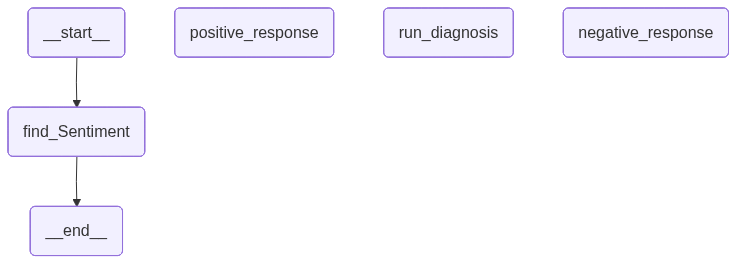

In [9]:
graph = StateGraph(ReviewState)
graph.add_node('find_Sentiment', find_Sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_Sentiment')
graph.add_conditional_edges('find_Sentiment',check_Sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
wfs = graph.compile()
wfs

In [10]:
init = {'review':'product is really good'}
final = wfs.invoke(init)
final

{'review': 'product is really good',
 'sentiment': 'Positive',
 'response': "Subject: Thank You for Your Review!\n\nDear [Customer's Name],\n\nThank you so much for taking the time to leave a review! We're thrilled to hear that you find our product to be really good. Your feedback means a lot to us and helps us continue to improve and provide quality products to our customers.\n\nIf you have any further thoughts or suggestions, please don't hesitate to reach out. We're always here to listen!\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Your Company Name]  \n[Your Contact Information]  "}

In [11]:

init = {'review':'product is really bad'}
final = wfs.invoke(init)
final

{'review': 'product is really bad',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'frustrated',
  'urgency': 'medium'},
 'response': "Subject: We're Here to Help!\n\nHi [User's Name],\n\nThank you for reaching out and for your patience. I completely understand how frustrating it can be when things aren't working as they should, and I want you to know that I'm here to help you resolve this issue as quickly as possible.\n\nCould you please provide a bit more detail about the problem you’re experiencing? This will help me assist you more effectively. If there are any specific error messages or behaviors that you've noticed, please include those, too.\n\nYour satisfaction is important to us, and I'm committed to finding a solution for you. I look forward to your response!\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Contact Information]  "}